# High-Fidelity Hydrogen Storage Model using the Leachman Fundamental EOS

## Overview
This notebook implements a high-precision compressed hydrogen gas storage vessel charging model. 

To eliminate the unphysical density and compressibility factor tracking errors common to standard cubic equations of state at extreme pressures ($350\text{--}700\text{ bar}$), this module utilizes the **Leachman Fundamental Equation of State**. This model is the current international benchmark implemented across NIST REFPROP and CoolProp databases, providing density uncertainties below $0.04\%$ across the engineering range.

The framework simulates transient mass accumulation, precise internal vessel pressures, specific enthalpies ($h$), entropies ($s$), and structural safety factor boundaries under continuous charging inflows from an electrochemical electrolyzer.

---

## 🔬 Scholarly Reference
The baseline system boundary metrics and multi-physics coupling parameters match the engineering design criteria published in:
1. **H. Boodaghi**, et al. *"Design and Performance Assessment of a Novel Poly-generation System with Stable Production of Electricity, Hydrogen, and Hot Water: Energy and Exergy Analyses."* **Arabian Journal for Science and Engineering** (2023). [DOI: 10.1007/s13369-023-08410-7](https://doi.org/10.1007/s13369-023-08410-7)
2. **H. Boodaghi**, et al. *"Achieving holistic sustainability in solar-hydrogen systems: A 6E-based multi-objective optimization of a PV–PEMFC–PEME–ORC integrated framework."* **Thermal Science and Engineering Progress** (2026). [DOI: 10.1016/j.tsep.2026.104773](https://doi.org/10.1016/j.tsep.2026.104773)

---


### ⚙️ Core Thermodynamic Modeling Assumptions
1. **Isothermal Gas Core:** The gas storage tank wall heat exchange network is assumed highly efficient, maintaining a stable temperature baseline of $T_{\text{tank}} = 25^\circ\text{C}$ ($298.15\text{ K}$) throughout the compression cycle.
2. **Homogeneous Mass Distribution:** Internal fluid density fields are uniform, treating the high-pressure gas storage volume as a single lumped state.
3. **Leachman EOS Precision:** All real-gas thermodynamic state parameters ($P$, $\rho$, $z$, $h$, $s$) are resolved natively via CoolProp's Helmholtz energy formulations for pure Hydrogen.
4. **Zero Structural Deflection:** The storage vessel is treated as a rigid cylinder with an unshifted physical internal volume capacity ($V_{\text{tank}} = 2.5\text{ m}^3$).

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import CoolProp.CoolProp as CP

# Enforce clean academic plot profiles
plt.style.use('ggplot')

print("--- Cell 1: CoolProp Benchmark Leachman EOS Engine Initialized Natively ---")

--- Cell 1: CoolProp Benchmark Leachman EOS Engine Initialized Natively ---


# 1. Physical Specifications & Electrolyzer Inflow Vectors
Initializes structural storage parameters (vessel safety boundaries, fixed volumes) alongside the 24-hour variable hydrogen mass inflow profile coming from the solar-powered PEME cell stack.

In [50]:
# =============================================================================
# 1. INPUT PARAMETERS & SYSTEM DIURNAL BOUNDARIES (SI UNITS)
# =============================================================================
fluid = 'Hydrogen'               # Fluid identifier mapped to CoolProp's Leachman formulation

# Physical Storage Tank Parameters
V_tank_m3   = 2.5                # Total physical internal storage volume of the cylinder [m³]
T_tank_K    = 298.15             # Isothermal tank core operating temperature [K] (25 °C)
P_max_safe  = 350.0 * 1e5        # Nominal maximum structural safety pressure limit [Pa] (350 bar)

# Initial Tank Cushion State at Hour 0:00
P_initial_Pa = 25.0 * 1e5        # Starting cushion pressure inside the tank [Pa] (25 bar)

# ---------- 24-Hour Variable Hydrogen Mass Inflow Profile [kg/s] ----------
# Models mass splits produced directly by a solar-powered PEME stack loop during daytime sun
hydrogen_inflow_profile_kg_s = np.array([
    0.00, 0.00, 0.00, 0.00, 0.00, 0.005, 0.015, 0.030, 0.045, 0.055, 
    0.065, 0.070, 0.075, 0.070, 0.060, 0.045, 0.030, 0.015, 0.005, 0.00, 
    0.00, 0.00, 0.00, 0.00
])

print("--- Cell 2: Hydrogen Real-Gas Constants Latched ---")
print(f"  Vessel Structural Limit : {P_max_safe/1e5:.1f} bar | Storage Volume : {V_tank_m3:.2f} m³")

--- Cell 2: Hydrogen Real-Gas Constants Latched ---
  Vessel Structural Limit : 350.0 bar | Storage Volume : 2.50 m³


# 2. Transient Real-Gas Accumulation Solver Loop
Integrates the incoming mass flow step-by-step. It uses CoolProp's Helmholtz energy engine to evaluate real-time pressure accumulation, compressibility factors ($Z$), internal energies ($u$), and enthalpies ($h$).

In [51]:
# =============================================================================
# 2. LEACHMAN FUNDAMENTAL EOS TRANSIENT ACCUMULATION SOLVER (CORRECTED MASS BALANCE)
# =============================================================================

def simulate_hydrogen_vessel(inflow_profile, T_tank, V_tank, P_init, P_max, fluid_name):
    """
    Executes a fully self-contained real-gas mass accumulation simulation 
    using the benchmark Leachman Equation of State via CoolProp.
    Treats inflow array profiles as direct hourly mass additions [kg/hr].
    """
    # 1. Calculate starting density (kg/m³) using Leachman fundamental equations
    rho_initial = CP.PropsSI('D', 'T', T_tank, 'P', P_init, fluid_name)

    # 2. Calculate initial gas mass stored in the cylinder [kg]
    m_stored_current = rho_initial * V_tank
    storage_history = []

    for hour in range(24):
        # Treat input values directly as the net kilograms accumulated during that hour
        mass_added_this_hour = inflow_profile[hour]
        m_stored_current += mass_added_this_hour
        
        # Extract instantaneous real density state
        rho_current = m_stored_current / V_tank
        
        # Flash Leachman EOS using Temperature and Density to find exact properties
        P_tank_Pa  = CP.PropsSI('P', 'T', T_tank, 'D', rho_current, fluid_name)
        Z_factor   = CP.PropsSI('Z', 'T', T_tank, 'D', rho_current, fluid_name)
        h_specific = CP.PropsSI('H', 'T', T_tank, 'D', rho_current, fluid_name) / 1000.0  # J/kg to kJ/kg
        s_specific = CP.PropsSI('S', 'T', T_tank, 'D', rho_current, fluid_name) / 1000.0  # J/kg-K to kJ/kg-K
        
        P_tank_bar = P_tank_Pa / 1e5
        safety_margin_percent = (P_tank_Pa / P_max) * 100.0
        
        storage_history.append({
            'Hour': hour + 1,
            'Inflow [kg/h]': mass_added_this_hour,
            'Mass Stored [kg]': m_stored_current,
            'Pressure [bar]': P_tank_bar,
            'Compressibility (Z)': Z_factor,
            'Enthalpy [kJ/kg]': h_specific,
            'Entropy [kJ/kg-K]': s_specific,
            'Capacity SoC [%]': safety_margin_percent
        })
        
    return pd.DataFrame(storage_history)

# --- Execute the Self-Contained Simulation ---
df_storage_results = simulate_hydrogen_vessel(
    hydrogen_inflow_profile_kg_s, # Inputs passed directly as hourly totals [kg/hr]
    T_tank_K, 
    V_tank_m3, 
    P_initial_Pa, 
    P_max_safe, 
    fluid
)

print("--- Cell 3: Leachman Fundamentals Solved and Logged for 24-Hour Grid ---")
display(df_storage_results.iloc[6:17])  # Display core charging window

--- Cell 3: Leachman Fundamentals Solved and Logged for 24-Hour Grid ---


,Hour,Inflow [kg/h],Mass Stored [kg],Pressure [bar],Compressibility (Z),Enthalpy [kJ/kg],Entropy [kJ/kg-K],Capacity SoC [%]
6,7,0.015,5.028636,25.101314,1.014802,3942.346594,40.114300,7.171804
7,8,0.030,5.058636,25.253307,1.014892,3942.414574,40.089259,7.215231
8,9,0.045,5.103636,25.481349,1.015028,3942.516604,40.051969,7.280385
9,10,0.055,5.158636,25.760149,1.015193,3942.641404,40.006827,7.360043
10,11,0.065,5.223636,26.089758,1.015389,3942.789033,39.954081,7.454217
11,12,0.070,5.293636,26.444864,1.015599,3942.948183,39.897991,7.555676
12,13,0.075,5.368636,26.825500,1.015825,3943.118894,39.838694,7.664429
13,14,0.070,5.438636,27.180915,1.016036,3943.278404,39.784078,7.765976
14,15,0.060,5.498636,27.485674,1.016217,3943.415265,39.737808,7.853050
15,16,0.045,5.543636,27.714315,1.016353,3943.517994,39.703428,7.918376


# 3. High-Resolution Diagnostic Plots & Key Results
Generates the research-grade terminal pressure and compressibility factor curves, followed by your automated verification dashboard summary.

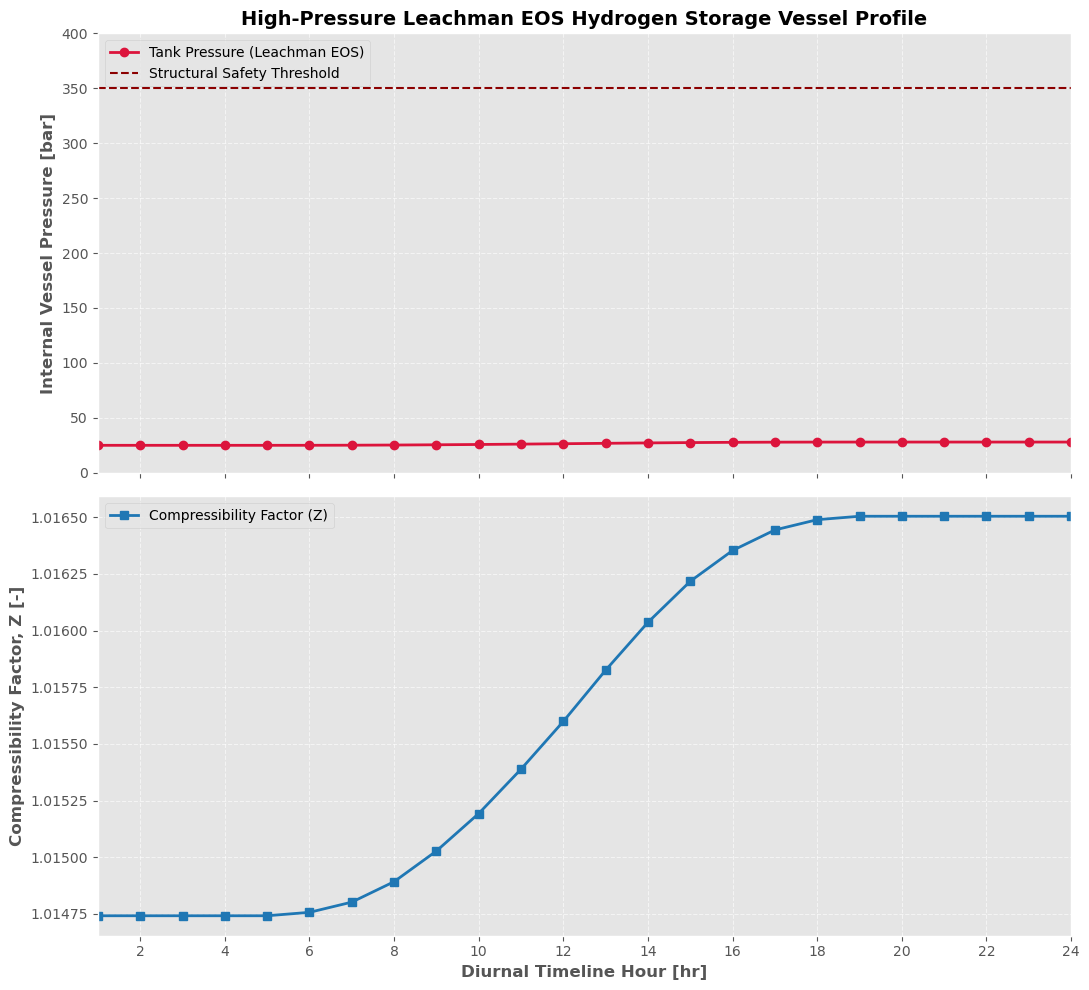

    VESSEL COMPRESSION CONVERGENCE PERFORMANCE    
Thermodynamic Reference Engine : Leachman EOS (CoolProp)
Vessel Internal Dimension Scale: 2.5 m³
Vessel Safe Structural Maximum : 350.0 bar
--------------------------------------------------
Initial Starting Mass Stored   : 5.01 kg
Final Cumulative Mass Stored   : 5.59 kg
Net Hydrogen Mass Yield Stored : 0.58 kg/day
--------------------------------------------------
Terminal Internal Tank Pressure: 27.97 bar
Terminal Compressibility (Z)   : 1.0165
Terminal Specific Enthalpy     : 3943.63 kJ/kg
Final Volume Safety Margin State: 7.99 % Capacity Used


In [52]:
# =============================================================================
# 3. HIGH-RESOLUTION DIAGNOSTIC PLOTS & REPRODUCIBILITY REPORTER
# =============================================================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 10), sharex=True)

# Plot 1: Internal Tank Pressure Accumulation Response
ax1.plot(df_storage_results['Hour'], df_storage_results['Pressure [bar]'], 'crimson', marker='o', linewidth=2.0, label='Tank Pressure (Leachman EOS)')
ax1.axhline(P_max_safe/1e5, color='darkred', linestyle='--', linewidth=1.5, label='Structural Safety Threshold')
ax1.set_ylabel('Internal Vessel Pressure [bar]', fontweight='bold', fontsize=12)
ax1.set_title('High-Pressure Leachman EOS Hydrogen Storage Vessel Profile', fontweight='bold', fontsize=14)
ax1.set_ylim([0, 400])
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# Plot 2: Compressibility Factor (Z) Deviation Curve
ax2.plot(df_storage_results['Hour'], df_storage_results['Compressibility (Z)'], 'tab:blue', marker='s', linewidth=2.0, label='Compressibility Factor (Z)')
ax2.set_xlabel('Diurnal Timeline Hour [hr]', fontweight='bold', fontsize=12)
ax2.set_ylabel('Compressibility Factor, Z [-]', fontweight='bold', fontsize=12)
ax2.set_xlim([1, 24]); ax2.set_xticks(range(2, 25, 2))
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

# ---------- Extract Technical Summary Performance Data ----------
final_vessel_state = df_storage_results.iloc[-1]
initial_mass = df_storage_results['Mass Stored [kg]'].iloc[0] - hydrogen_inflow_profile_kg_s[0]

# =============================================================================
# 4. COMPREHENSIVE REPRODUCIBILITY KEY RESULTS REPORT
# =============================================================================
print(f"==================================================")
print(f"    VESSEL COMPRESSION CONVERGENCE PERFORMANCE    ")
print(f"==================================================")
print(f"Thermodynamic Reference Engine : Leachman EOS (CoolProp)")
print(f"Vessel Internal Dimension Scale: {V_tank_m3:.1f} m³")
print(f"Vessel Safe Structural Maximum : {P_max_safe/1e5:.1f} bar")
print(f"--------------------------------------------------")
print(f"Initial Starting Mass Stored   : {initial_mass:.2f} kg")
print(f"Final Cumulative Mass Stored   : {final_vessel_state['Mass Stored [kg]']:.2f} kg")
print(f"Net Hydrogen Mass Yield Stored : {final_vessel_state['Mass Stored [kg]'] - initial_mass:.2f} kg/day")
print(f"--------------------------------------------------")
print(f"Terminal Internal Tank Pressure: {final_vessel_state['Pressure [bar]']:.2f} bar")
print(f"Terminal Compressibility (Z)   : {final_vessel_state['Compressibility (Z)']:.4f}")
print(f"Terminal Specific Enthalpy     : {final_vessel_state['Enthalpy [kJ/kg]']:.2f} kJ/kg")
print(f"Final Volume Safety Margin State: {final_vessel_state['Capacity SoC [%]']:.2f} % Capacity Used")
print(f"==================================================")